#Install libraries

In [1]:
pip install pandas numpy scikit-learn nltk gensim matplotlib seaborn beautifulsoup4 langdetect


In [2]:
pip install jupyter

#Load and inspect data

In [3]:
import pandas as pd

df = pd.read_csv("Reviews.csv")

print(df.shape)
print(df.columns)
df.head()

(568454, 10)
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


#Remove duplicates

In [5]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (568454, 10)


#Handle missing values in column summary

In [6]:
df["Summary"] = df["Summary"].fillna("")

#Combine Summary and Text
This becomes the input text for the model.

In [7]:
df["review_text"] = df["Summary"] + " " + df["Text"]

#Remove HTML Tags

In [8]:
from bs4 import BeautifulSoup

def remove_html(text):
    return BeautifulSoup(text, "html.parser").get_text()

df["review_text"] = df["review_text"].apply(remove_html)

#Convert Text to Lowercase

In [9]:
df["review_text"] = df["review_text"].str.lower()

#Remove Punctuation & Special Characters

In [10]:
import re

def remove_punctuation(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

df["review_text"] = df["review_text"].apply(remove_punctuation)

#Remove Non-English Reviews

In [11]:
from langdetect import detect

def is_english(text):
    try:
        return detect(text) == "en"
    except:
        return False

df = df[df["review_text"].apply(is_english)]

#Tokenization

In [13]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import word_tokenize

df["tokens"] = df["review_text"].apply(word_tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


#Stopword Removal

In [14]:
nltk.download("stopwords")
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(
    lambda words: [w for w in words if w not in stop_words]
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#Lemmatization

In [15]:
nltk.download("wordnet")
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["tokens"] = df["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(w) for w in words]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...


#Convert Time → Year

In [16]:
df["Time"] = pd.to_datetime(df["Time"], unit="s")
df["Year"] = df["Time"].dt.year

#Filter Year ≥ 2010

In [17]:
df = df[df["Year"] >= 2010]

#Remove Unnecessary Columns

In [18]:
df = df[["Score", "review_text", "tokens", "Year"]]

#Save Clean Dataset

In [19]:
df.to_csv("clean_reviews.csv", index=False)

#EDA
***
##Score Distribution (Class Imbalance)

The Purpose Is To Understand how many reviews belong to each score (1–5).


/tmp/ipykernel_6894/3712234181.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Score", data=df, palette="viridis")


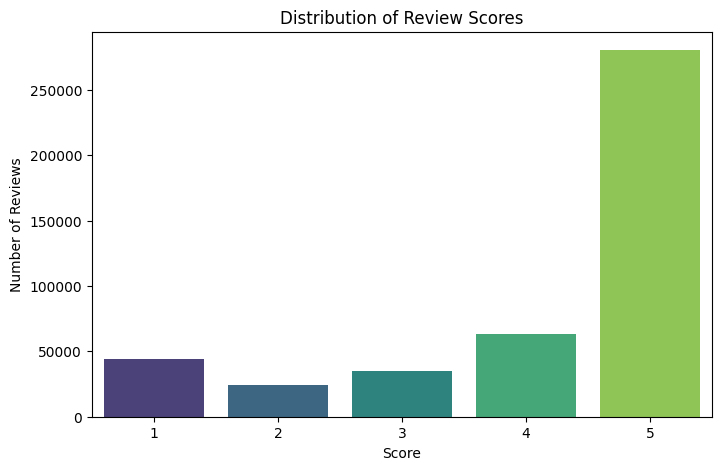

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x="Score", data=df, palette="viridis")

plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Number of Reviews")

plt.show()

The distribution of review scores shows a strong class imbalance, with the majority of reviews being 5-star ratings. This imbalance can bias machine learning models toward predicting the majority class. Therefore, stratified sampling is later applied to balance the training dataset.

##Review Length Distribution

The Purpose Is To Understand how long reviews are and how much text the models will process.

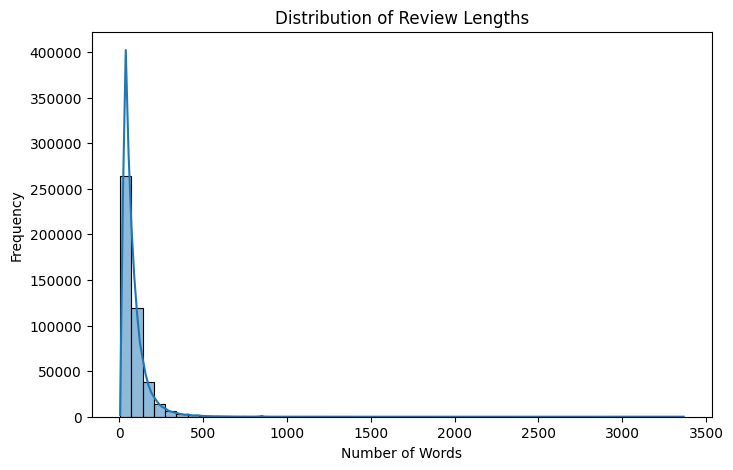

In [23]:
df["review_length"] = df["review_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df["review_length"], bins=50, kde=True)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

The distribution of review lengths shows that most reviews are relatively short, while a smaller number of reviews contain significantly longer text. This variation highlights the importance of text preprocessing and feature extraction methods capable of handling variable-length inputs.

##Most Frequent Words

The Purpose Is To Identify common words in the dataset after cleaning.

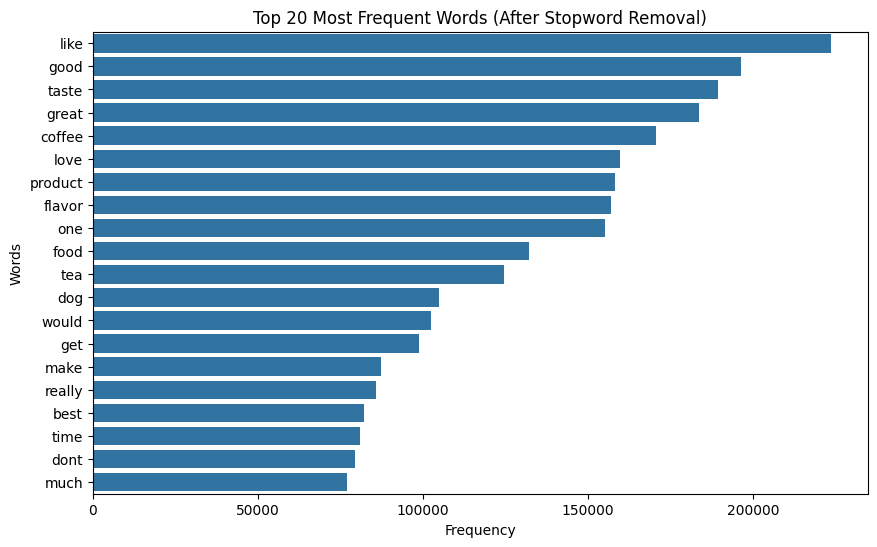

In [25]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten the list of tokens
all_tokens = [word for tokens in df["tokens"] for word in tokens]

word_counts = Counter(all_tokens)

common_words = word_counts.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,6))
sns.barplot(x=counts, y=words)

plt.title("Top 20 Most Frequent Words (After Stopword Removal)")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

The most frequent words in the dataset are primarily related to product descriptions and customer experiences. Common words such as “taste,” “product,” and “good” appear frequently across reviews, indicating that users often discuss product quality and flavor in their feedback.

##Word Cloud

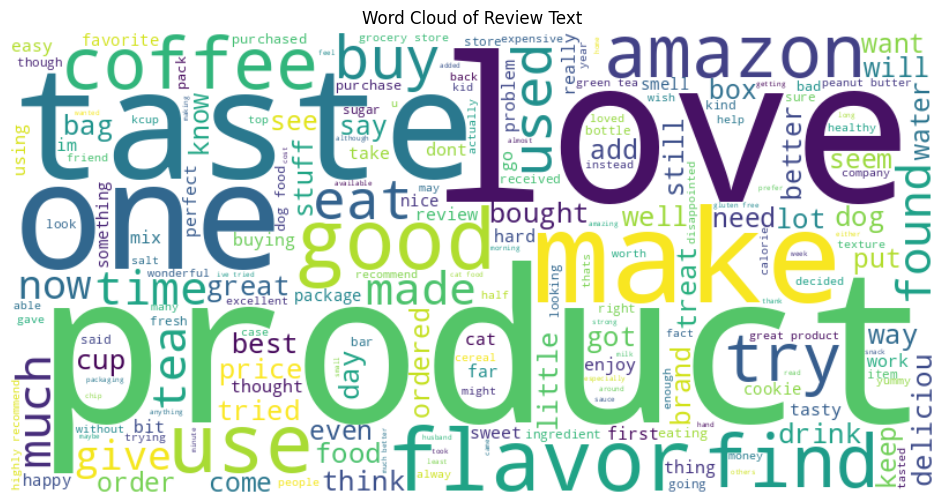

In [28]:
!pip install wordcloud
from wordcloud import WordCloud

text = " ".join(df["review_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Review Text")

plt.show()

The word cloud highlights frequently occurring terms within the reviews. Words related to product taste, quality, and customer satisfaction appear prominently, reflecting the dominant themes discussed by customers.

##Reviews Per Year

The Purpose Is To observe how reviews are distributed over time and supports filtering 2010 onward.

/tmp/ipykernel_6894/2177877778.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Year", data=df, palette="coolwarm")


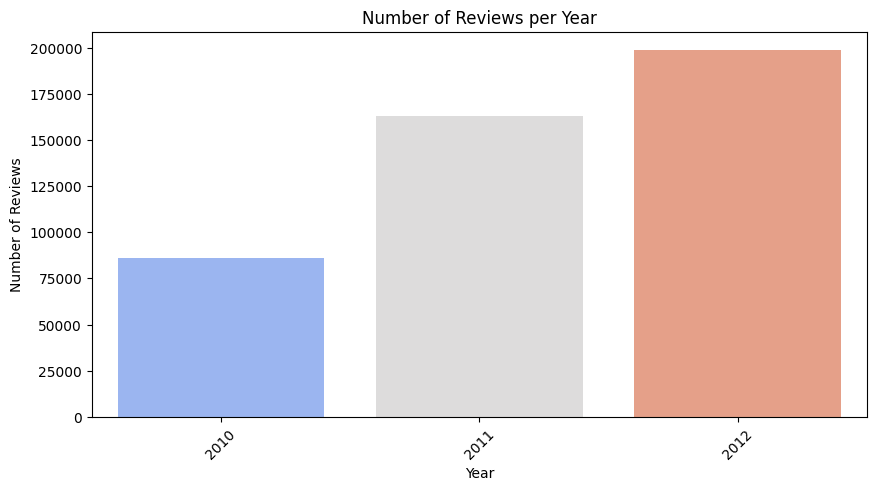

In [29]:
plt.figure(figsize=(10,5))

sns.countplot(x="Year", data=df, palette="coolwarm")

plt.xticks(rotation=45)
plt.title("Number of Reviews per Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.show()

The distribution of reviews across years indicates an increase in review activity over time. To focus on more recent consumer behavior and reduce potential temporal bias, reviews from 2010 onwards are retained for further analysis.

The exploratory data analysis reveals several key characteristics of the dataset. First, the review scores are highly imbalanced, with a large proportion of 5-star ratings. Second, review lengths vary significantly across entries, indicating the need for robust feature extraction techniques. Additionally, common words within the dataset largely relate to product quality and taste. Finally, the temporal distribution of reviews supports the decision to focus on reviews from 2010 onward for more recent and relevant data.

In [20]:
# If the above doesn't work, try this nuclear option:
import json
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

with open(filename, 'r') as f:
    nb = json.load(f)

# Completely remove widgets metadata (safest for GitHub)
if 'metadata' in nb:
    if 'widgets' in nb['metadata']:
        del nb['metadata']['widgets']

# Save and download
with open(f"data_cleaning_and_eda_{filename}", 'w') as f:
    json.dump(nb, f, indent=2)

files.download(f"data_cleaning_and_eda_{filename}")

Saving amazon_fine_food_review_score_prediction.ipynb to amazon_fine_food_review_score_prediction.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>